# Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA

/content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA


In [ ]:
!pip install -U pip

!pip install \
  transformers==4.38.2 \
  datasets==2.18.0 \
  accelerate==0.27.2 \
  sentencepiece \
  tqdm \
  scikit-learn \
  attrdict


# Finance Data - Test on some samples

In [4]:
import pandas as pd

df = pd.read_csv('../data/dev.csv')   # recheck data path in drive to match with this
df.head()

,published_at,ticker,true_sentiment,title,author,url,source,text,finbert_sentiment,finbert_sent_score,external_context_1,external_context_2,external_context_3
0,2023-01-18 15:24:00,EURCHF,Negative,EURCHF Bias would be for stronger Franc but wa...,FXStreet Insights Team,https://www.fxstreet.com/news/eur-chf-bias-wou...,FX Street,Economists at Credit Suisse are now neutral o...,Neutral,0.08,"Financial Sector Update for 01/18/2023: PNC, B...","Financial Sector Update for 01/18/2023: PNC, B...","Financial Sector Update for 01/18/2023: PNC, B..."
1,2023-01-20 04:59:00,EURCHF,Negative,New lows for the EURUSD. EURCHF down as well a...,Greg Michalowski,https://www.forexlive.com/technical-analysis/n...,Forex Live,New low for the EURUSD as it remains the curre...,Negative,-0.93,European Stocks Climb Early in New Year: An ET...,Vanguard Real Estate ETF Experiences Big Outfl...,Vanguard Real Estate ETF Experiences Big Outfl...
2,2023-01-12 11:40:00,EURCHF,Neutral,Does a jump in EURCHF point to a break above 1...,FXStreet Insights Team,https://www.fxstreet.com/news/does-a-jump-in-e...,FX Street,EUR/CHF vaults parity for the first time since...,Neutral,0.37,"Down -29.05% in 4 Weeks, Here's Why You Should...",CEE MARKETS-FX drifts before U.S. inflation da...,Bear Market Watch: What Will Mean a Bull Marke...
3,2023-01-13 19:48:00,EURCHF,Neutral,USDCHF stalls its run higher at the 200 bar MA...,Greg Michalowski,https://www.forexlive.com/technical-analysis/u...,Forex Live,The USDCHF is sharply higher on the day helped...,Positive,0.77,CEE MARKETS-Forint climbs back near 5-month hi...,BBCA Breaks Above 200-Day Moving Average - Bul...,EWC Makes Bullish Cross Above Critical Moving ...
4,2023-01-12 07:47:00,EURCHF,Positive,Euro to benefit from the ECBs pronounced hawki...,FXStreet Insights Team,https://www.fxstreet.com/news/euro-to-benefit-...,FX Street,The Euro was able to appreciate particularly s...,Positive,0.85,CEE MARKETS-FX drifts before U.S. inflation da...,European shares rise as investors await U.S. i...,MOVES-Rothschild & Co appoint Horn as capital ...


In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "google/flan-t5-xl"   # stable on Colab
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [6]:
def build_multihop_prompt(title, ticker):
    return f"""
You are a financial sentiment analysis assistant.

Your task is to determine the **relative sentiment of the base currency versus the quote currency**
for the forex ticker **{ticker}**, based only on the given news title.

Follow these steps carefully:

Hop 1 – Entity Grounding:
- Identify the base currency and the quote currency in the ticker {ticker}.
- Determine which currency the title mainly discusses or implies impact on.

Hop 2 – Identify Financial Aspect:
- Identify the main economic or financial driver mentioned or implied
  (e.g., central bank policy, inflation, interest rates, growth outlook, risk sentiment).

Hop 3 – Identify Implicit Cues:
- Detect indirect or implicit signals such as:
  • Hedging language (e.g., "may", "could", "expects")
  • Euphemisms (e.g., "challenging environment")
  • Indirect warnings (e.g., "headwinds", "pressure")
  • Mixed or defensive framing

Hop 4 – Infer Relative Sentiment:
- Based on the above, infer whether the **base currency is expected to strengthen,
  weaken, or remain neutral relative to the quote currency**.

Hop 5 – Infer Market Implication:
- Translate the relative sentiment into market direction:
  • Strengthening base vs quote → Bullish
  • Weakening base vs quote → Bearish
  • Unclear or mixed → Uncertain

Title:
{title}

Final answer (one word only, based on relative movement of base vs quote):
Positive (base stronger), Neutral, or Negative (base weaker).
""".strip()

In [ ]:
def infer_multihop(row):
    title = row['title']
    ticker = row['ticker']
    context = row['text']
    prompt = build_multihop_prompt(title, ticker)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=20,
            temperature=0.0
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
for i in range(10):
    row = df.iloc[i]
    pred = infer_multihop(row)

    print("="*60)
    print("TITLE:", row['title'])
    print("TRUE :", row['true_sentiment'])
    print("PRED :", pred)


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TITLE: Euro to benefit from the ECBs pronounced hawkish determination – Commerzbank
TRUE : Positive
PRED : Positive
TITLE: EURCHF Trend higher may remain in place – ING
TRUE : Positive
PRED : Positive
TITLE: Does a jump in EURCHF point to a break above 108 in EURUSD – SocGen
TRUE : Neutral
PRED : Positive
TITLE: EURCHF could extend its advance back to levels between 102 and 104 – MUFG
TRUE : Positive
PRED : Positive
TITLE: EURCHF to head higher towards 10130 and projections of 1024010260 – SocGen
TRUE : Positive
PRED : Positive
TITLE: EURCHF Room for the Euro to extend the move higher – MUFG
TRUE : Positive
PRED : Positive
TITLE: USDCHF stalls its run higher at the 200 bar MA on the 4 hour chart and 38.2% retracement
TRUE : Neutral
PRED : Neutral
TITLE: EURCHF reaches 38.2% of the 2 year range as run higher continues
TRUE : Positive
PRED : Positive
TITLE: EURCHF Bias would be for stronger Franc but waiting for clearer SNB monetary policy stance – Credit Suisse
TRUE : Negative
PRED : Ne

# Finance Data - Experiment on full data

### Setup

In [4]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [5]:
df = pd.read_csv("data/finance/data_with_context.csv")   # recheck data path in drive to match with this

TEXT_COL = "title"
TICKER_COL = "ticker"
LABEL_COL = "true_sentiment"
FINBERT_COL = "finbert_sentiment"
IN_CONTEXT_COL = "text"
EX_CONTEXT_1_COL = "external_context_1"
EX_CONTEXT_2_COL = "external_context_2"
EX_CONTEXT_3_COL = "external_context_3"

df.head()


,published_at,ticker,true_sentiment,title,author,url,source,text,finbert_sentiment,finbert_sent_score,external_context_1,external_context_2,external_context_3
0,2023-01-12 07:47:00,EURCHF,Positive,Euro to benefit from the ECBs pronounced hawki...,FXStreet Insights Team,https://www.fxstreet.com/news/euro-to-benefit-...,FX Street,The Euro was able to appreciate particularly s...,Positive,0.85,CEE MARKETS-FX drifts before U.S. inflation da...,European shares rise as investors await U.S. i...,MOVES-Rothschild & Co appoint Horn as capital ...
1,2023-01-12 10:34:00,EURCHF,Positive,EURCHF Trend higher may remain in place – ING,FXStreet Insights Team,https://www.fxstreet.com/news/eur-chf-trend-hi...,FX Street,EUR/CHF yesterday broke above 1.00. Economists...,Positive,0.51,European shares rise as investors await U.S. i...,CEE MARKETS-FX drifts before U.S. inflation da...,European shares rise as investors await U.S. i...
2,2023-01-12 11:40:00,EURCHF,Neutral,Does a jump in EURCHF point to a break above 1...,FXStreet Insights Team,https://www.fxstreet.com/news/does-a-jump-in-e...,FX Street,EUR/CHF vaults parity for the first time since...,Neutral,0.37,"Down -29.05% in 4 Weeks, Here's Why You Should...",CEE MARKETS-FX drifts before U.S. inflation da...,Bear Market Watch: What Will Mean a Bull Marke...
3,2023-01-12 15:32:00,EURCHF,Positive,EURCHF could extend its advance back to levels...,FXStreet Insights Team,https://www.fxstreet.com/news/eur-chf-could-ex...,FX Street,EUR/CHF climbs back above parity. Economists a...,Positive,0.64,CEE MARKETS-FX drifts before U.S. inflation da...,Bullish Two Hundred Day Moving Average Cross -...,"SPSM, AMN, FN, SPSC: ETF Inflow Alert\n\nLooki..."
4,2023-01-13 11:37:00,EURCHF,Positive,EURCHF to head higher towards 10130 and projec...,FXStreet Insights Team,https://www.fxstreet.com/news/eur-chf-to-head-...,FX Street,EUR/CHF has broken out above the sideways rang...,Positive,0.83,CEE MARKETS-Forint climbs back near 5-month hi...,"SOXS, EGPT: Big ETF Inflows\n\nComparing units...","SOXS, EGPT: Big ETF Inflows\n\nComparing units..."


### Load LLM

##### Flan

In [6]:
device = 0 if torch.cuda.is_available() else -1

pipe = pipeline(
    "text2text-generation",
    model="google/flan-t5-xl",  # xxl causes OOM locally
    device=device,
    batch_size=8
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.45G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

### Prompt Helper

In [7]:
def truncate_context(text, max_words):
    if not isinstance(text, str):
        return ""
    words = text.split()
    return " ".join(words[:max_words])


### Prompt Design

In [8]:
# get from chatgpt paper, will fix this for evaluation purpose (72%)

def prompt_only(title, ticker):
    return f"""
Act as an expert at forex trading.
Classify the sentiment for ***{ticker}*** based only on the headline '{title}'
Answer in one token: Positive, Negative, or Neutral
""".strip()


In [ ]:
# v1 (68%)

def multihop_prompt(title, ticker):
    return f"""
Act as an expert at forex trading.

Your task is to classify the sentiment for ***{ticker}*** based only on the headline '{title}'

Follow these steps carefully:

Hop 1 – Entity Grounding:
- Identify the base currency and the quote currency in the ticker {ticker}.
- Determine which currency the title mainly discusses or implies impact on.

Hop 2 – Identify Financial Aspect:
- Identify the main economic or financial driver mentioned or implied
  (e.g., central bank policy, inflation, interest rates, growth outlook, risk sentiment).

Hop 3 – Identify Implicit Cues:
- Detect indirect or implicit signals such as:
  • Hedging language (e.g., "may", "could", "expects")
  • Euphemisms (e.g., "challenging environment")
  • Indirect warnings (e.g., "headwinds", "pressure")
  • Mixed or defensive framing

Hop 4 – Infer Relative Sentiment:
- Based on the above, infer whether the **base currency is expected to strengthen,
  weaken, or remain neutral relative to the quote currency**.

Hop 5 – Infer Market Implication:
- Translate the relative sentiment into market direction:
  • Strengthening base vs quote → Bullish
  • Weakening base vs quote → Bearish
  • Unclear or mixed → Uncertain

Answer in one token: Positive, Negative, or Neutral
""".strip()


In [9]:
# v2 (74% - best version till now)

def multihop_prompt(title, ticker):
    return f"""
Act as an expert at forex trading.

Classify the sentiment for {ticker} based only on the headline.

Reason internally using these steps:
1) Identify which currency is mainly affected.
2) Identify whether the news implies strength or weakness.
3) Compare base vs quote currency.

Headline: "{title}"

Answer in one token only: Positive, Negative, or Neutral.
""".strip()


In [ ]:
# v3 (73%)

def multihop_prompt(title, ticker):
    return f"""
Act as an expert at forex trading.

Classify the sentiment for {ticker} based only on the headline.

Reason internally using these steps:
1) Identify which currency is mainly affected.
2) Identify whether the news implies strength or weakness
   relative to market expectations.
3) Compare base vs quote currency and infer direction.
4) If a directional bias exists, do not choose Neutral.

Headline: "{title}"

Answer with exactly one token: Positive, Negative, or Neutral.
""".strip()


In [23]:
# v2 with RAG (1)

def multihop_rag_prompt(title, ticker, text, ext1):

    text = truncate_context(text, 50)
    ext1 = truncate_context(ext1, 50)

    return f"""
Act as an expert at forex trading.

This is a STRICT classification task.

Classify the sentiment for {ticker} based mainly on the headline.

DECISION RULES (must follow in order):
1) First decide if the headline ALONE clearly implies Positive, Negative, or Neutral sentiment.
2) If the headline is CLEAR, IGNORE ALL CONTEXT.
3) Only if the headline is AMBIGUOUS, you MAY use context.
4) Context may ONLY confirm or clarify strength vs weakness — it must NOT introduce new sentiment.
5) Descriptive, technical, forecast, or analyst commentary MUST be ignored.

Reason internally using these steps:
1) Identify which currency is mainly affected.
2) Identify whether the news implies strength or weakness.
3) Compare base vs quote currency.

Headline:
"{title}"

Optional context (use ONLY if the headline is ambiguous):

Main article text:
{text}

External context:
{ext1}

Final answer:
Choose EXACTLY ONE token (case-sensitive), with no explanation:
Positive
Negative
Neutral
""".strip()


In [10]:
# v2 with RAG (2)

def multihop_rag_prompt(title, ticker, text, ext1):

    text = truncate_context(text, 120)
    ext1 = truncate_context(ext1, 80)

    return f"""
Act as an expert at forex trading.

This is a STRICT classification task.

Classify the sentiment for {ticker} based mainly on the headline.

DECISION RULES (must follow in order):
1) First decide if the headline ALONE clearly implies Positive, Negative, or Neutral sentiment.
2) If the headline is CLEAR, IGNORE ALL CONTEXT.
3) Only if the headline is AMBIGUOUS, you MAY use context.
4) Context may ONLY confirm or clarify strength vs weakness — it must NOT introduce new sentiment.
5) Descriptive, technical, forecast, or analyst commentary MUST be ignored.

Reason internally using these steps:
1) Identify which currency is mainly affected.
2) Identify whether the news implies strength or weakness.
3) Compare base vs quote currency.

Headline:
"{title}"

Optional context (use ONLY if the headline is ambiguous):

{text}

Final answer:
Choose EXACTLY ONE token (case-sensitive), with no explanation:
Positive
Negative
Neutral
""".strip()


### LLM Inference Helper

In [11]:
hf_ds = Dataset.from_pandas(df)


##### Prefict with Flan

In [12]:
def run_prompt_batch(batch):
    prompts = [
        prompt_only(t, tk)
        for t, tk in zip(batch[TEXT_COL], batch[TICKER_COL])
    ]
    outputs = pipe(prompts, max_new_tokens=5, truncation=True)
    batch["prompt_pred"] = [o["generated_text"].strip() for o in outputs]
    return batch

hf_ds = hf_ds.map(run_prompt_batch, batched=True, batch_size=8)

Map:   0%|          | 0/2291 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


In [13]:
def run_multihop_batch(batch):
    prompts = [
        multihop_prompt(t, tk)
        for t, tk in zip(batch[TEXT_COL], batch[TICKER_COL])
    ]
    outputs = pipe(prompts, max_new_tokens=20, truncation=True)
    batch["multihop_pred"] = [o["generated_text"].strip() for o in outputs]
    return batch

hf_ds = hf_ds.map(run_multihop_batch, batched=True, batch_size=8)

Map:   0%|          | 0/2291 [00:00<?, ? examples/s]

In [24]:
def run_multihop_rag_batch(batch):
    prompts = [
        multihop_rag_prompt(t, tk, ic, ec1)
        for t, tk, ic, ec1 in zip(batch[TEXT_COL], batch[TICKER_COL], batch[IN_CONTEXT_COL], batch[EX_CONTEXT_1_COL])
    ]
    outputs = pipe(prompts, max_new_tokens=20, truncation=True)
    batch["multihop_rag_pred"] = [o["generated_text"].strip() for o in outputs]
    return batch

hf_ds = hf_ds.map(run_multihop_rag_batch, batched=True, batch_size=8)

Map:   0%|          | 0/2291 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


### Back to Pandas

In [15]:
df = hf_ds.to_pandas()

# optinal
df["multihop_rag_pred"] = df["multihop_rag_pred"].str.capitalize()

df[[TEXT_COL, TICKER_COL, LABEL_COL, FINBERT_COL, "prompt_pred", "multihop_pred", "multihop_rag_pred"]].head()

,title,ticker,true_sentiment,finbert_sentiment,prompt_pred,multihop_pred,multihop_rag_pred
0,Euro to benefit from the ECBs pronounced hawki...,EURCHF,Positive,Positive,Positive,Positive,Positive
1,EURCHF Trend higher may remain in place – ING,EURCHF,Positive,Positive,Positive,Positive,Positive
2,Does a jump in EURCHF point to a break above 1...,EURCHF,Neutral,Neutral,Positive,Positive,Positive
3,EURCHF could extend its advance back to levels...,EURCHF,Positive,Positive,Positive,Positive,Positive
4,EURCHF to head higher towards 10130 and projec...,EURCHF,Positive,Positive,Positive,Positive,Positive


In [22]:
# # save df to csv file with result
# df.to_csv("data/finance/data_with_results.csv", index=False)


### Evaluation

In [17]:
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("-" * 40)
    return acc, f1


In [18]:
results = []

# MODEL_NAME = pipe.model.config._name_or_path  # in case using Flan
# MODEL_NAME = pipe.model.config._name_or_path + "-withContext" # in case using Flan with context
# MODEL_NAME = gemini_model._model_name.replace("models/", "")  # in case using Gemini
MODEL_NAME = "Flan T5 xl with New 5-hop v2 + RAG (2)"

print("Using model:", MODEL_NAME)

def log_result(strategy_name, acc, f1):
    results.append({
        "Model": MODEL_NAME,
        "Strategy": strategy_name,
        "Accuracy": acc,
        "F1-score": f1
    })

y_true = df[LABEL_COL]

finbert_acc, finbert_f1 = evaluate(
    y_true, df[FINBERT_COL], "FinBERT (dataset)"
)
log_result("FinBERT (dataset)", finbert_acc, finbert_f1)

prompt_acc, prompt_f1 = evaluate(
    y_true, df["prompt_pred"], "Prompt-only (1-step)"
)
log_result("Prompt-only (1-step)", prompt_acc, prompt_f1)

multihop_acc, multihop_f1 = evaluate(
    y_true, df["multihop_pred"], "Multi-hop"
)
log_result("Multi-hop", multihop_acc, multihop_f1)


multihop_rag_acc, multihop_rag_f1 = evaluate(
    y_true, df["multihop_rag_pred"], "Multi-hop with RAG"
)
log_result("Multi-hop with RAG", multihop_rag_acc, multihop_rag_f1)


Using model: Flan T5 xl with New 5-hop v2 + RAG (2)
FinBERT (dataset)
Accuracy: 0.5618
F1-score: 0.5589
----------------------------------------
Prompt-only (1-step)
Accuracy: 0.7272
F1-score: 0.7295
----------------------------------------
Multi-hop
Accuracy: 0.7420
F1-score: 0.7469
----------------------------------------
Multi-hop with RAG
Accuracy: 0.7591
F1-score: 0.7608
----------------------------------------


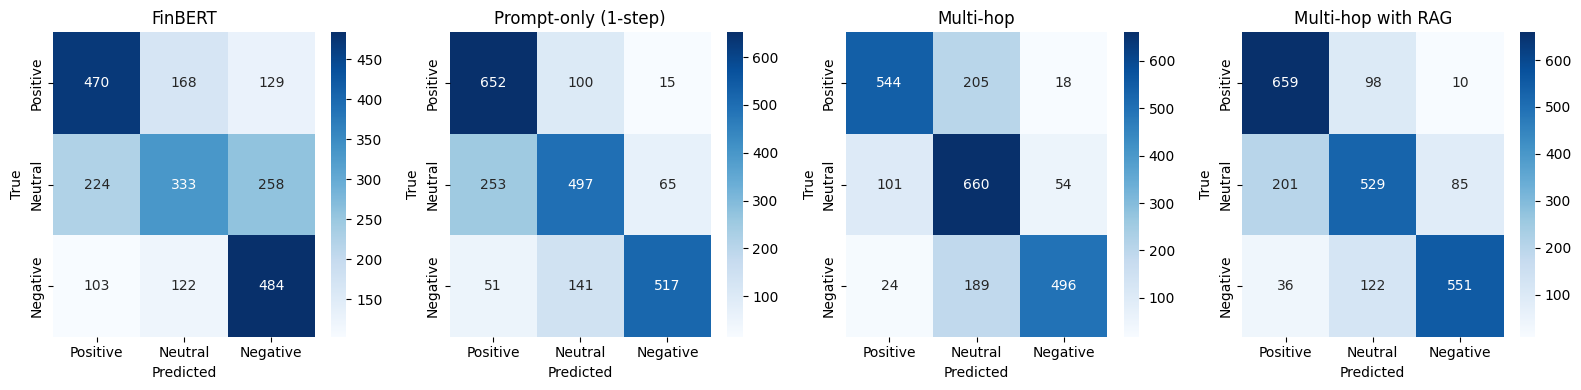

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["Positive", "Neutral", "Negative"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

cms = [
    confusion_matrix(y_true, df[FINBERT_COL], labels=labels),
    confusion_matrix(y_true, df["prompt_pred"], labels=labels),
    confusion_matrix(y_true, df["multihop_pred"], labels=labels),
    confusion_matrix(y_true, df["multihop_rag_pred"], labels=labels)
]

titles = [
    "FinBERT",
    "Prompt-only (1-step)",
    "Multi-hop",
    "Multi-hop with RAG"
]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


In [20]:
results_df = pd.DataFrame(results)
results_df


,Model,Strategy,Accuracy,F1-score
0,Flan T5 xl with New 5-hop v2 + RAG (2),FinBERT (dataset),0.561763,0.558942
1,Flan T5 xl with New 5-hop v2 + RAG (2),Prompt-only (1-step),0.727193,0.729534
2,Flan T5 xl with New 5-hop v2 + RAG (2),Multi-hop,0.742034,0.746914
3,Flan T5 xl with New 5-hop v2 + RAG (2),Multi-hop with RAG,0.759057,0.760766


In [ ]:
import os

CSV_PATH = "sentiment_results.csv"

if os.path.exists(CSV_PATH):
    old_df = pd.read_csv(CSV_PATH)

    # assume model name column is called "model"
    if results_df["Model"].iloc[0] not in old_df["Model"].values:
        results_df = pd.concat([old_df, results_df], ignore_index=True)
    else:
        print("⚠️ Model already exists, not appending")
        results_df = old_df

results_df.to_csv(CSV_PATH, index=False)